### Imports

In [1]:
from fundus_dataset import AugmentPair, FundusVesselDataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from safetensors.torch import save_file
from pathlib import Path
from common_utils import get_datasets, get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Testing the Dataset

In [3]:
img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

train_full, val_full = get_datasets(img_dir, mask_dir, transform=AugmentPair(crop_size=(512, 512)))
train_loader, val_loader = get_dataloaders(train_full, val_full)


## Sanity checking
images, masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("Train images:", images.shape, images.dtype, images.min().item(), images.max().item())
print("Train masks: ", masks.shape, masks.dtype, torch.unique(masks))
print("Val images:", val_images.shape, val_images.dtype, val_images.min().item(), val_images.max().item())
print("Val masks: ", val_masks.shape, val_masks.dtype, torch.unique(val_masks))

Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Train size: 480
Val size: 120


Train images: torch.Size([4, 3, 512, 512]) torch.float32 0.0 1.0
Train masks:  torch.Size([4, 1, 512, 512]) torch.float32 tensor([0., 1.])
Val images: torch.Size([1, 3, 2048, 2048]) torch.float32 0.0 1.0
Val masks:  torch.Size([1, 1, 2048, 2048]) torch.float32 tensor([0., 1.])


### BCEDice Loss Functions

In [3]:
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, w_dice=0.5):
        super().__init__()
        self.w_bce = w_bce
        self.w_dice = w_dice

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(sigmoid=True)

    def forward(self, logits, masks):
        bce = self.bce(logits, masks)
        dice = self.dice(logits, masks)

        return self.w_bce * bce + self.w_dice * dice

def hard_dice_score(logits, masks, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    # flatten each image separately: [B, 1, H, W] -> [B, pixels]
    preds = preds.flatten(start_dim=1)
    masks = masks.flatten(start_dim=1)

    intersection = (preds * masks).sum(dim=1)
    denominator = preds.sum(dim=1) + masks.sum(dim=1)

    dice = (2 * intersection + eps) / (denominator + eps)

    return dice.mean()

### U-Net Factory

In [6]:
def make_unet(channels=(16, 32, 64, 128, 256)):
    model = UNet(
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=channels,
        strides=(2, 2, 2, 2),
        num_res_units=2,
    )
    return model.to(device)

### Training Loop Function

In [5]:
def validate_full_image(model, loader, loss_fn, threshold=0.5):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            dice = hard_dice_score(logits, masks, threshold=threshold)

            val_loss += loss.item() * images.size(0)
            val_dice += dice.item() * images.size(0)

    val_loss /= len(loader.dataset)
    val_dice /= len(loader.dataset)
    return val_loss, val_dice


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, save_path=None, save_name="baseline.safetensors"):
    history = []
    best_val_dice = 0.0
    best_epoch = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_loss_steps = []

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_fn(logits, masks)

            loss.backward()
            optimizer.step()

            step_loss = loss.item()
            train_loss += step_loss * images.size(0)
            train_loss_steps.append(step_loss)

        train_loss /= len(train_loader.dataset)

        # Default validation protocol: full-image metrics on val_loader.
        val_loss, val_dice = validate_full_image(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            threshold=0.5,
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_loss_steps": train_loss_steps,
            "val_loss": val_loss,
            "val_dice": val_dice,
        })

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1

            if save_path is not None:
                save_dir = Path(save_path)
                save_dir.mkdir(parents=True, exist_ok=True)
                st_path = save_dir / save_name
                save_file(model.state_dict(), st_path)

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Best: {best_val_dice:.4f} @ {best_epoch}"
        )

    return history

### DANGEROUS (RESET EXPERIMENT)

In [6]:
model = make_unet(channels=(32, 64, 128, 256, 512))
loss_fn = BCEDiceLoss(w_bce=0.5, w_dice=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 100
SAVE_PATH = "/workspace/models_baseline/"
SAVE_NAME = "baseline.safetensors"

### START OR CONTINUE EXPERIMENT

In [7]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    save_path=SAVE_PATH,
    save_name=SAVE_NAME,
)

Epoch 001/100 | Train loss: 0.6968 | Val loss: 0.6780 | Val Dice: 0.6360 | Best: 0.6360 @ 1
Epoch 002/100 | Train loss: 0.6364 | Val loss: 0.6266 | Val Dice: 0.6560 | Best: 0.6560 @ 2
Epoch 003/100 | Train loss: 0.5776 | Val loss: 0.5630 | Val Dice: 0.7270 | Best: 0.7270 @ 3
Epoch 004/100 | Train loss: 0.5156 | Val loss: 0.4924 | Val Dice: 0.7755 | Best: 0.7755 @ 4
Epoch 005/100 | Train loss: 0.4407 | Val loss: 0.4312 | Val Dice: 0.7700 | Best: 0.7755 @ 4
Epoch 006/100 | Train loss: 0.3859 | Val loss: 0.3670 | Val Dice: 0.7566 | Best: 0.7755 @ 4
Epoch 007/100 | Train loss: 0.3265 | Val loss: 0.2956 | Val Dice: 0.7994 | Best: 0.7994 @ 7
Epoch 008/100 | Train loss: 0.2615 | Val loss: 0.2196 | Val Dice: 0.8378 | Best: 0.8378 @ 8
Epoch 009/100 | Train loss: 0.2280 | Val loss: 0.1853 | Val Dice: 0.8360 | Best: 0.8378 @ 8
Epoch 010/100 | Train loss: 0.1898 | Val loss: 0.1554 | Val Dice: 0.8492 | Best: 0.8492 @ 10
Epoch 011/100 | Train loss: 0.1724 | Val loss: 0.1372 | Val Dice: 0.8578 | Best

### Save your Settings

In [9]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv("/workspace/models_baseline/baseline_history.csv", index=False)

### Training Graphs

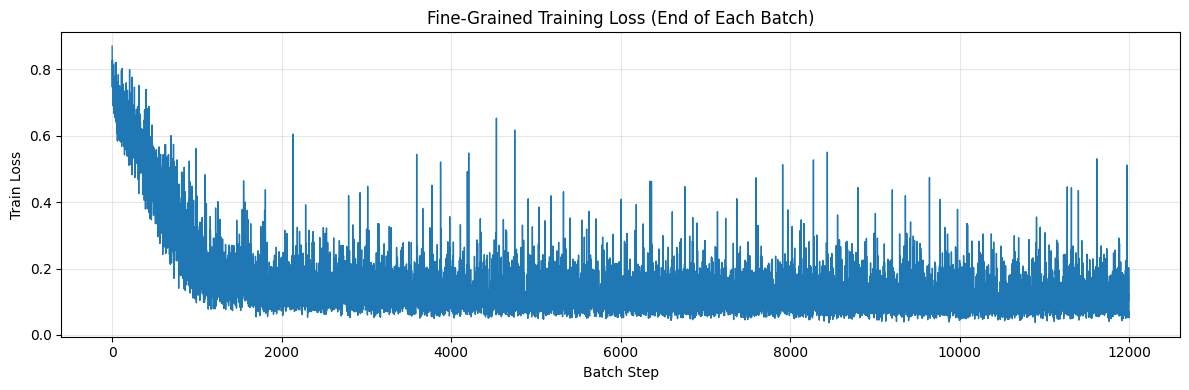

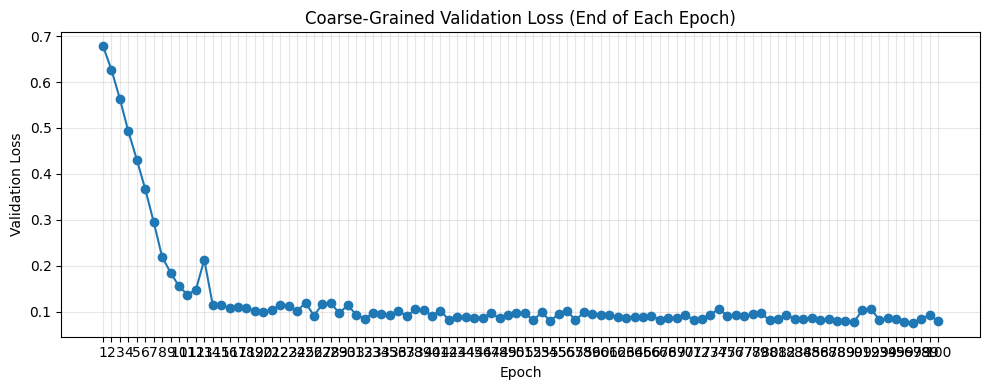

Loaded 100 epochs from /workspace/models_baseline/baseline_history.csv
Plotted 12000 batch-level training-loss points


In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

history_csv = "/workspace/models_baseline/baseline_history.csv"
history_df = pd.read_csv(history_csv)

required_cols = {"epoch", "train_loss_steps", "val_loss"}
missing_cols = required_cols - set(history_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in {history_csv}: {sorted(missing_cols)}")

# Parse stringified step-loss lists safely.
train_loss_steps_per_epoch = history_df["train_loss_steps"].apply(ast.literal_eval)

batch_steps = []
train_step_losses = []
step_idx = 1

for epoch_steps in train_loss_steps_per_epoch:
    batch_steps.extend(range(step_idx, step_idx + len(epoch_steps)))
    train_step_losses.extend(epoch_steps)
    step_idx += len(epoch_steps)

plt.figure(figsize=(12, 4))
plt.plot(batch_steps, train_step_losses, linewidth=1)
plt.title("Fine-Grained Training Loss (End of Each Batch)")
plt.xlabel("Batch Step")
plt.ylabel("Train Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", linewidth=1.5)
plt.title("Coarse-Grained Validation Loss (End of Each Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loaded {len(history_df)} epochs from {history_csv}")
print(f"Plotted {len(train_step_losses)} batch-level training-loss points")

### Hard Evaluation Functions

Here we load a model safetensors file and then perform inference on it. We will evaluate on the following metrics:


1. Binary Statistics (Dice, IoU, Precision, Recall, F1)
2. $B_0$ and $B_1$ topological errors

In [19]:
import torch


def binary_segmentation_metrics(y_true: torch.Tensor, y_pred: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7):
    """
    Compute Dice, IoU, precision, recall, and F1 for binary segmentation.
    """

    # We need to detach the tensors to avoid gradient computation
    y_true = y_true.detach()
    y_pred = y_pred.detach()

    # Threshold the predictions
    y_true = (y_true > 0.5).float()
    y_pred = (y_pred > threshold).float()

    # This gives 1D vectors
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)

    tp = torch.sum((y_pred == 1) & (y_true == 1)).float()
    fp = torch.sum((y_pred == 1) & (y_true == 0)).float()
    fn = torch.sum((y_pred == 0) & (y_true == 1)).float()
    tn = torch.sum((y_pred == 0) & (y_true == 0)).float()

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)  # This is literally the same as Dice, but we'll keep it for clarity

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "tp": tp.item(),
        "fp": fp.item(),
        "fn": fn.item(),
        "tn": tn.item(),
    }

In [23]:
import torch
import numpy as np
from scipy import ndimage


def beta0_beta1_2d(binary_mask: np.ndarray):
    """
    Computes Betti numbers for a 2D binary mask. 

    b_0 is the number of connected foreground components
    b_1 is the number of enclosed background holes inside foreground
    """
    binary_mask = binary_mask.astype(bool)

    # Foreground connectivity.
    # 4-connectivity is conservative for thin structures.
    fg_structure = ndimage.generate_binary_structure(2, 1)
    _, beta0 = ndimage.label(binary_mask, structure=fg_structure)

    # Background components.
    # Holes are background components that do NOT touch the image border.
    background = ~binary_mask

    # 8-connectivity for background is often paired with 4-connectivity foreground
    # to avoid ambiguous diagonal connections.
    bg_structure = ndimage.generate_binary_structure(2, 2)
    bg_labels, num_bg = ndimage.label(background, structure=bg_structure)

    if num_bg == 0:
        beta1 = 0
        return beta0, beta1

    border_labels = set()

    border_labels.update(np.unique(bg_labels[0, :]))
    border_labels.update(np.unique(bg_labels[-1, :]))
    border_labels.update(np.unique(bg_labels[:, 0]))
    border_labels.update(np.unique(bg_labels[:, -1]))

    # Label 0 is not a real component.
    border_labels.discard(0)

    all_bg_labels = set(range(1, num_bg + 1))
    hole_labels = all_bg_labels - border_labels

    beta1 = len(hole_labels)

    return beta0, beta1

def betti_error_one_image(
    logits: torch.Tensor,
    mask: torch.Tensor,
    threshold: float = 0.5,
    b0_weight: float = 1.0,
    b1_weight: float = 1.0,
):
    """
    Computes non-differentiable Betti error for one predicted mask and one GT mask.

    Args:
        logits: [1, H, W] or [H, W], raw model output for one image
        mask:   [1, H, W] or [H, W], binary ground truth mask
        threshold: probability threshold for binarizing prediction
        b0_weight: weight for beta0 error
        b1_weight: weight for beta1 error

    Returns:
        loss: scalar torch.Tensor, useful for logging
        stats: dict with Betti numbers and errors for this image
    """
    probs = torch.sigmoid(logits)
    pred = (probs > threshold).float()

    pred_np = pred.detach().cpu().numpy()
    mask_np = mask.detach().cpu().numpy()

    # Remove channel dimension if present: [1, H, W] -> [H, W]
    if pred_np.ndim == 3: pred_np = pred_np[0]

    if mask_np.ndim == 3: mask_np = mask_np[0]

    b0_pred, b1_pred = beta0_beta1_2d(pred_np)
    b0_gt, b1_gt = beta0_beta1_2d(mask_np)

    b0_error = abs(b0_pred - b0_gt)
    b1_error = abs(b1_pred - b1_gt)

    total_error = b0_weight * b0_error + b1_weight * b1_error

    loss = torch.tensor(total_error, device=logits.device, dtype=logits.dtype)

    stats = {
        "betti_loss": float(total_error),
        "b0_error": b0_error,
        "b1_error": b1_error,
        "betti_error": b0_error + b1_error,
        "b0_pred": b0_pred,
        "b1_pred": b1_pred,
        "b0_gt": b0_gt,
        "b1_gt": b1_gt,
    }

    return loss, stats

### Firm Evaluation Functions

The hard versions of the Losses: clDice, Skeleton Recall, cbDice

### Perform Evaluation

In [26]:
from statistics import mean

import torch
from torch.utils.data import DataLoader
from safetensors.torch import load_file

test_ds = FundusVesselDataset(
    img_dir="fundus/test/Original/",
    mask_dir="fundus/test/Ground truth",
    transform=None,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

eval_model = make_unet(channels=(32, 64, 128, 256, 512)).to(device)
eval_model.load_state_dict(load_file("/workspace/models_baseline/baseline.safetensors"))
eval_model.eval()


rows = []

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        name = test_ds.images[idx]

        images = images.to(device)
        masks = masks.to(device)

        logits = eval_model(images)
        probs = torch.sigmoid(logits)

        _, betti_stats = betti_error_one_image(logits[0], masks[0], threshold=0.5, b0_weight=1.0, b1_weight=1.0)

        row = {"image": name, **binary_segmentation_metrics(masks, probs, threshold=0.5), **betti_stats}
        rows.append(row)


# -----------------------
# Print mean results
# -----------------------

binary_keys = ["dice", "iou", "precision", "recall", "f1"]
betti_keys = ["b0_error", "b1_error", "betti_error"]

print("Mean binary metrics:")
for key in binary_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

print("\nMean Betti / topological errors:")
for key in betti_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

Number of images: 200
Number of masks: 200
First 5 image files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']
First 5 mask files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']


Mean binary metrics:
  dice: 0.871277
  iou: 0.783450
  precision: 0.896569
  recall: 0.852270
  f1: 0.871277

Mean Betti / topological errors:
  b0_error: 91.775000
  b1_error: 11.725000
  betti_error: 103.500000


### Top 5 Worst $B_0$

$B_0$ (the 0th Betti number $\beta_0$) counts how many **connected components** the segmented **foreground** (vessels) has under 4-connectivity—the same quantity computed in `beta0_beta1_2d`. The per-image field `b0_error` is the absolute difference between predicted and ground-truth component counts. **Worst** cases here are the five test images with the **largest** `b0_error` (e.g. many spurious fragments or merged regions vs. the reference mask).

    image  b0_gt  b0_pred  b0_error  b1_error     dice
177_N.png     15      288       273         1 0.876007
178_N.png     14      278       264         6 0.857823
166_N.png     19      270       251        20 0.859034
145_G.png     24      246       222        18 0.764195
175_N.png     16      211       195        35 0.882170


/tmp/ipykernel_2657/377410309.py:38: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


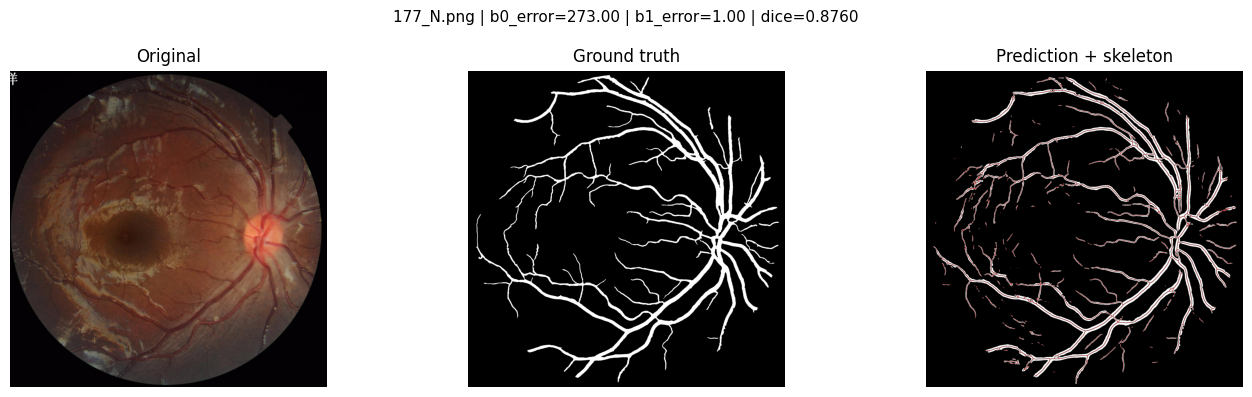

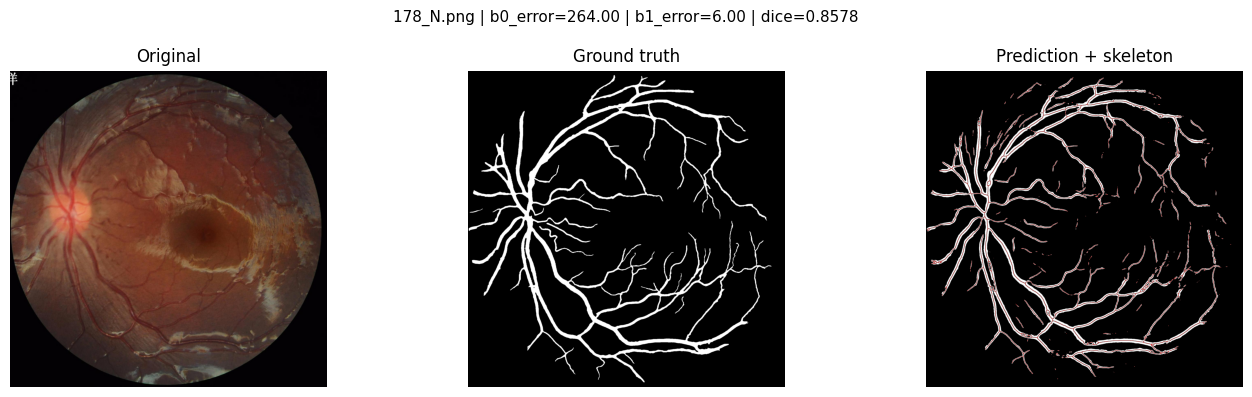

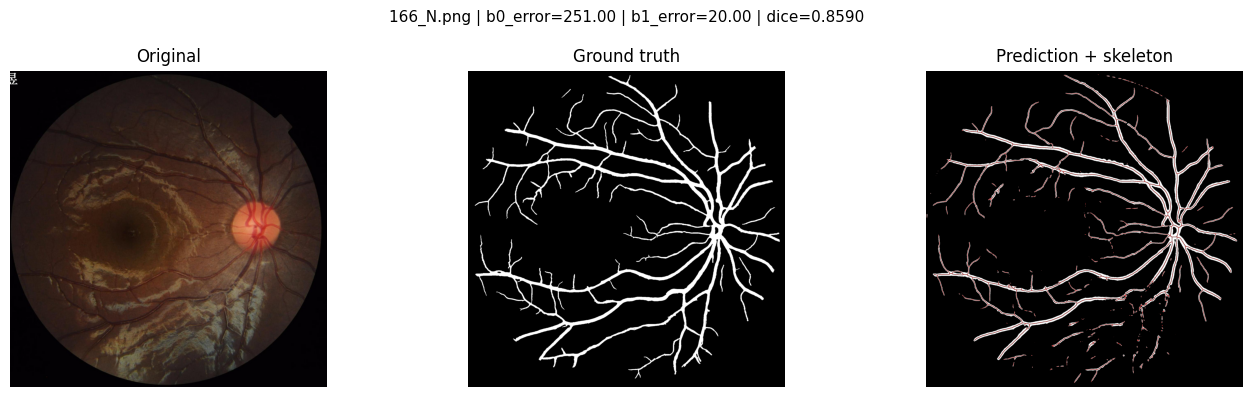

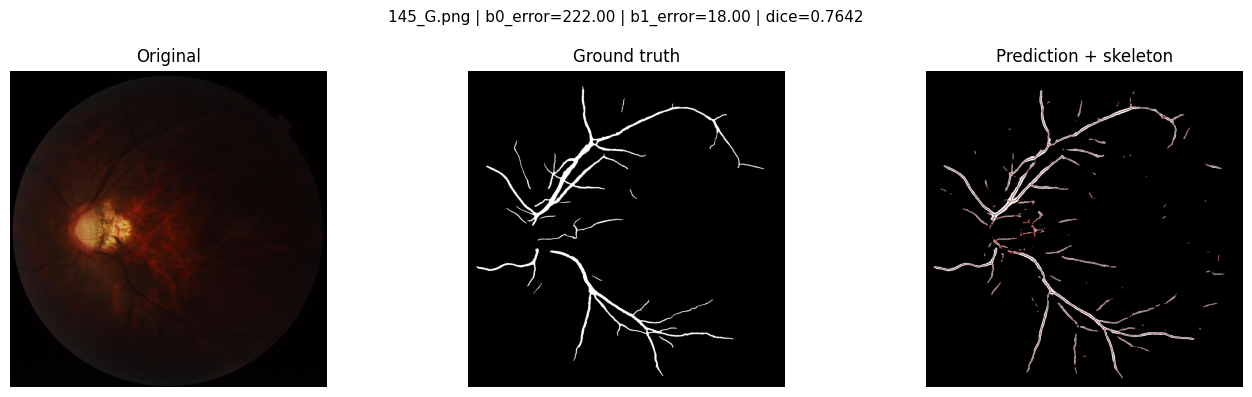

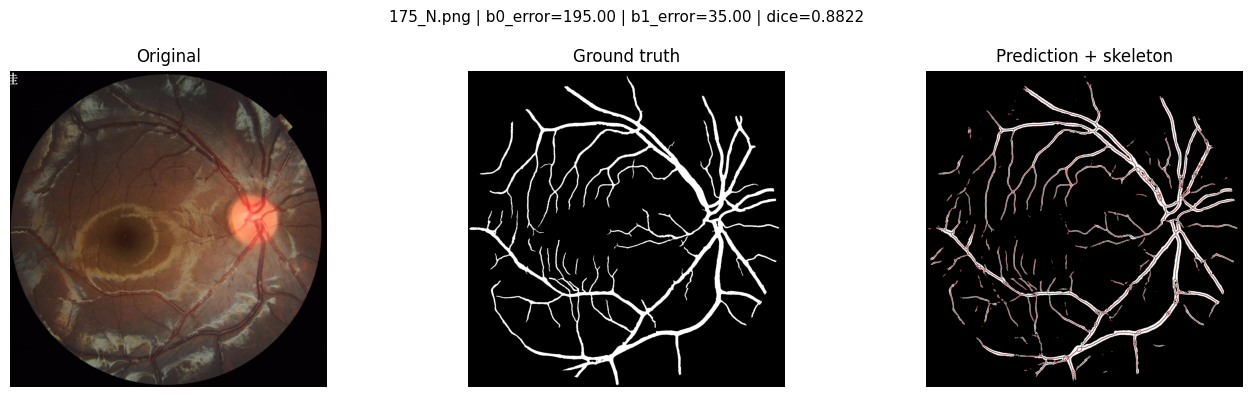

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from skimage.morphology import skeletonize, binary_dilation


# -----------------------
# Find worst 5 by B0 error
# -----------------------

top5_b0 = sorted(rows, key=lambda r: r["b0_error"], reverse=True)[:5]

summary = pd.DataFrame(top5_b0)[
    ["image", "b0_gt", "b0_pred", "b0_error", "b1_error", "dice"]
]

print(summary.to_string(index=False))


# -----------------------
# Helpers
# -----------------------

def predict_mask(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]


def make_skeleton_overlay(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )


def show_b0_example(row):
    image_name = row["image"]
    idx = test_ds.images.index(image_name)

    image, mask = test_ds[idx]

    pred_mask = predict_mask(eval_model, image)
    skeleton_overlay = make_skeleton_overlay(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"b0_error={row['b0_error']:.2f} | "
        f"b1_error={row['b1_error']:.2f} | "
        f"dice={row['dice']:.4f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# -----------------------
# Plot worst examples
# -----------------------

eval_model.eval()

for row in top5_b0:
    show_b0_example(row)

### Top 5 Worst $B_1$

$B_1$ (the 1st Betti number $\beta_1$) counts **holes**: background regions fully enclosed by foreground (8-connected background, ignoring components that touch the image border), as in `beta0_beta1_2d`. The field `b1_error` is the absolute difference between predicted and ground-truth hole counts. **Worst** cases are the five images with the **largest** `b1_error`—typically extra “donut” false positives or missed interior gaps vs. the ground truth.

    image  b1_gt  b1_pred  b1_error  b0_error     dice
 62_D.png     79        0        79        94 0.661249
 91_D.png     79       14        65        79 0.880300
126_G.png     63        4        59        53 0.901339
175_N.png     26       61        35       195 0.882170
137_G.png     33        0        33        70 0.702001


/tmp/ipykernel_2657/3990854543.py:41: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


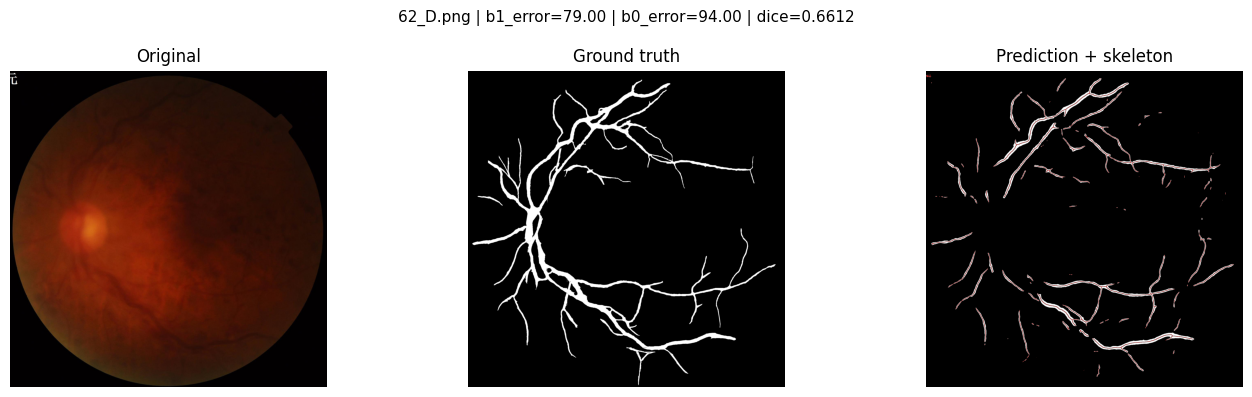

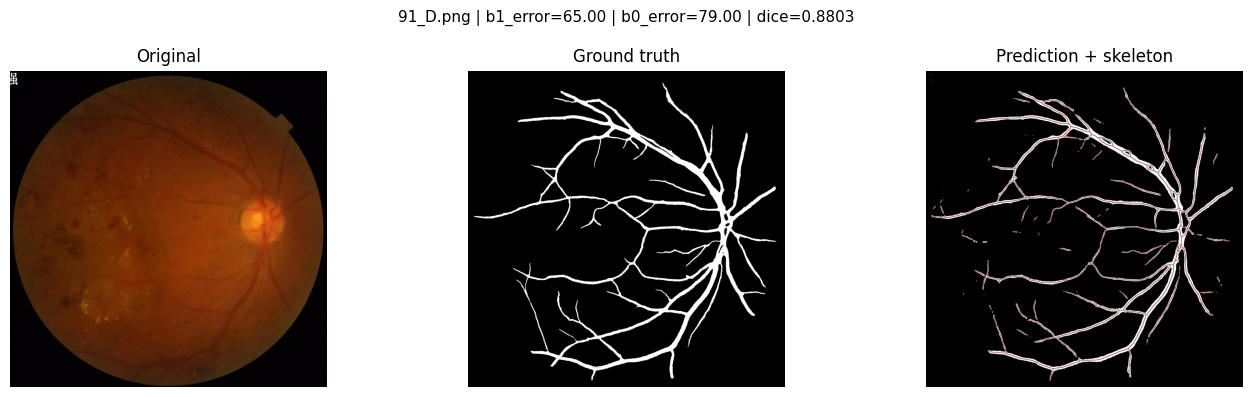

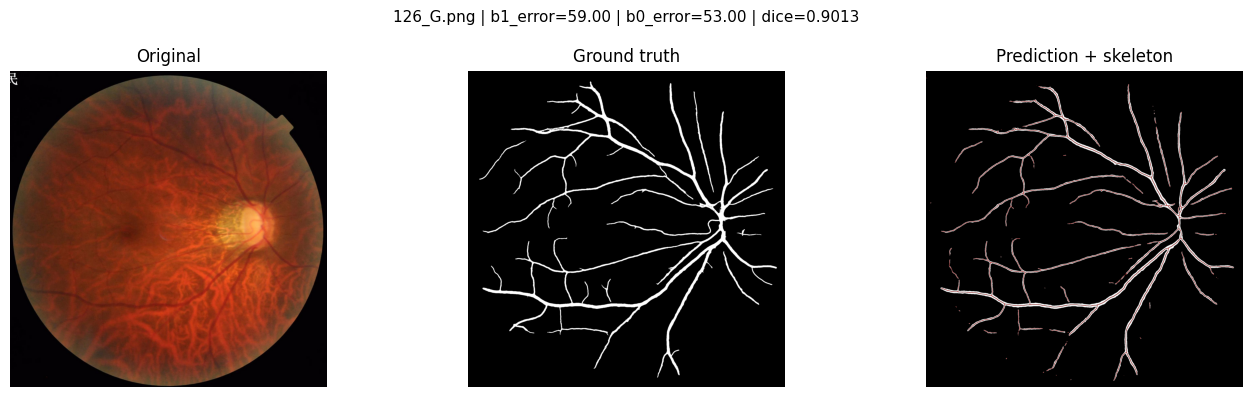

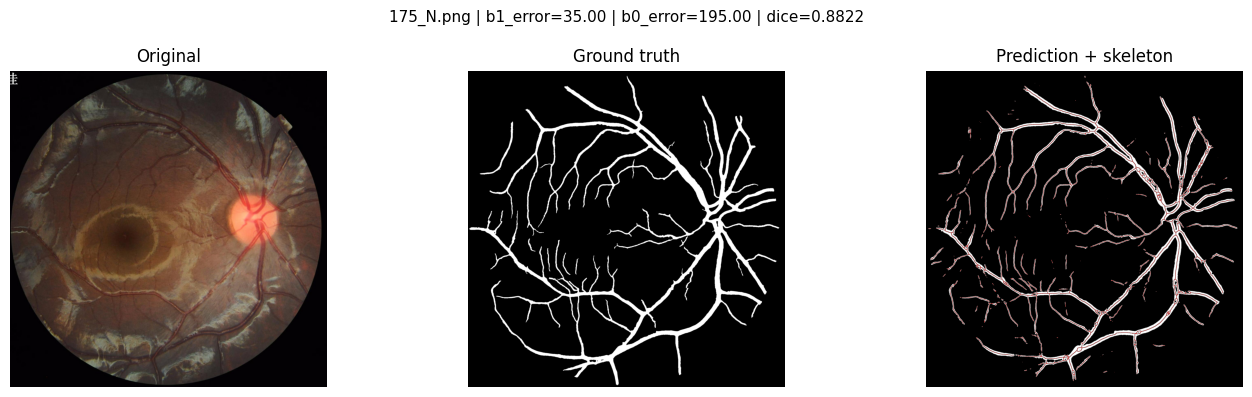

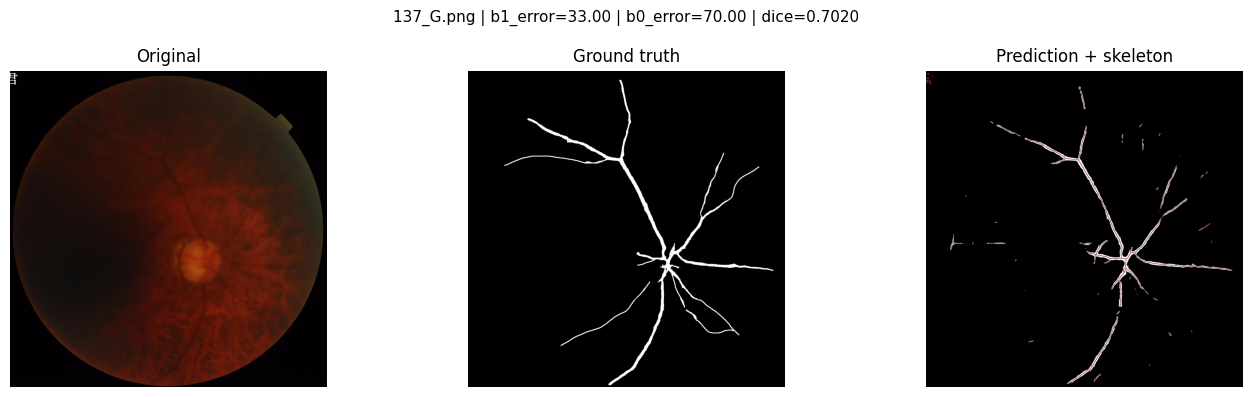

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from skimage.morphology import skeletonize, binary_dilation


# -----------------------
# Find worst 5 by B1 error
# -----------------------

top5_b1 = sorted(rows, key=lambda r: r["b1_error"], reverse=True)[:5]

summary = pd.DataFrame(top5_b1)[
    ["image", "b1_gt", "b1_pred", "b1_error", "b0_error", "dice"]
]

print(summary.to_string(index=False))


# -----------------------
# Helpers
# -----------------------

name_to_idx = {name: idx for idx, name in enumerate(test_ds.images)}


def predict_mask(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]


def make_skeleton_overlay(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )


def show_b1_example(row):
    image_name = row["image"]
    idx = name_to_idx[image_name]

    image, mask = test_ds[idx]

    pred_mask = predict_mask(eval_model, image)
    skeleton_overlay = make_skeleton_overlay(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"b1_error={row['b1_error']:.2f} | "
        f"b0_error={row['b0_error']:.2f} | "
        f"dice={row['dice']:.4f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# -----------------------
# Plot worst examples
# -----------------------

eval_model.eval()

for row in top5_b1:
    show_b1_example(row)

### Utilities

In [16]:
import os
import torch
import matplotlib.pyplot as plt

save_dir = "/workspace/models/qualitative"
os.makedirs(save_dir, exist_ok=True)

model = eval_model

model.eval()

num_examples_to_save = 8
saved = 0

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(val_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        batch_size = images.size(0)

        for idx in range(batch_size):
            if saved >= num_examples_to_save:
                break

            fig = plt.figure(figsize=(12, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(images[idx].cpu().permute(1, 2, 0))
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(masks[idx, 0].cpu(), cmap="gray")
            plt.title("Ground truth")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(probs[idx, 0].cpu(), cmap="gray", vmin=0, vmax=1)
            plt.title("Probability")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(preds[idx, 0].cpu(), cmap="gray", vmin=0, vmax=1)
            plt.title("Prediction")
            plt.axis("off")

            plt.tight_layout()

            out_path = os.path.join(
                save_dir,
                f"bce_dice_val_example_{saved:02d}.png"
            )

            plt.savefig(out_path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            print("Saved:", out_path)

            saved += 1

        if saved >= num_examples_to_save:
            break

print(f"Saved {saved} qualitative examples to {save_dir}")

Saved: /workspace/models/qualitative/bce_dice_val_example_00.png
Saved: /workspace/models/qualitative/bce_dice_val_example_01.png
Saved: /workspace/models/qualitative/bce_dice_val_example_02.png
Saved: /workspace/models/qualitative/bce_dice_val_example_03.png
Saved: /workspace/models/qualitative/bce_dice_val_example_04.png
Saved: /workspace/models/qualitative/bce_dice_val_example_05.png
Saved: /workspace/models/qualitative/bce_dice_val_example_06.png
Saved: /workspace/models/qualitative/bce_dice_val_example_07.png
Saved 8 qualitative examples to /workspace/models/qualitative
